In [1]:
import os

DATA_PATH = "/kaggle/input/jazbatai-data"

# List all files in the directory
files = [f for f in os.listdir(DATA_PATH) if os.path.isfile(os.path.join(DATA_PATH, f))]
files = files[:5]  # take only first 5

print("Found files:", files)

def count_sentences_blank_line(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        content = f.read()
    # Data in each Split by double newlines (blank lines)
    sentences = [s.strip() for s in content.split("\n\n") if s.strip()]

    return len(sentences)
    
# Process each file
for file_name in files:
    full_path = os.path.join(DATA_PATH, file_name)
    
    num_sentences = count_sentences_blank_line(full_path)
    
    print(f"File: {file_name}")
    print(f"Number of sentences (blank-line separated): {num_sentences}")
    print("--------------------------------------------")


Found files: ['training_data_sarcasam.txt', 'training_data_joy.txt', 'training_data_anger.txt', 'training_data_sadness.txt', 'training_data_neutral.txt']
File: training_data_sarcasam.txt
Number of sentences (blank-line separated): 932
--------------------------------------------
File: training_data_joy.txt
Number of sentences (blank-line separated): 1529
--------------------------------------------
File: training_data_anger.txt
Number of sentences (blank-line separated): 999
--------------------------------------------
File: training_data_sadness.txt
Number of sentences (blank-line separated): 1110
--------------------------------------------
File: training_data_neutral.txt
Number of sentences (blank-line separated): 1031
--------------------------------------------


In [2]:
!pip install transformers datasets torch accelerate scikit-learn matplotlib seaborn tqdm pandas numpy -q
!pip install wandb -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 28.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.5 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 61.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 32.9 MB/s eta 0:00:0000:0100:01m
ERROR: pip's dep

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import os
import re
import random
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


🚀 Starting data loading process...
🔄 Loading emotion data...
   ✅ training_data_anger.txt: 999 samples loaded as 'anger'
   ✅ training_data_joy.txt: 1529 samples loaded as 'joy'
   ✅ training_data_sadness.txt: 1110 samples loaded as 'sadness'
   ✅ training_data_sarcasam.txt: 932 samples loaded as 'sarcasm'
   ✅ training_data_neutral.txt: 1031 samples loaded as 'neutral'

📊 Dataset Summary:
   Total samples: 5601
   Emotions distribution:
      joy: 1529 samples
      sadness: 1110 samples
      neutral: 1031 samples
      anger: 999 samples
      sarcasm: 932 samples


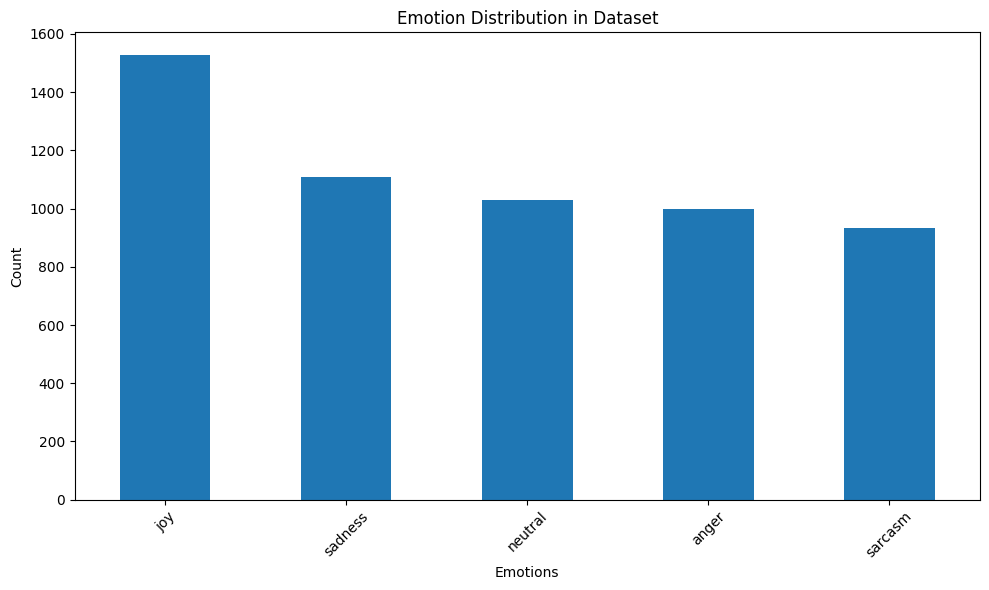

In [4]:
# Load and prepare the dataset with proper validation
def load_jazbatAI_data():
    data = []
    labels = []
    
    # Define all your emotion files
    emotion_files = {
        'training_data_anger.txt': 'anger',
        'training_data_joy.txt': 'joy', 
        'training_data_sadness.txt': 'sadness',
        'training_data_sarcasam.txt': 'sarcasm',
        'training_data_neutral.txt': 'neutral'
    }
    
    print("🔄 Loading emotion data...")
    # Load data from each emotion file
    for file_name, emotion in emotion_files.items():
        try:
            file_path = f'/kaggle/input/jazbatai-data/{file_name}'
            if os.path.exists(file_path):
                with open(file_path, 'r', encoding='utf-8') as f:
                    lines = [line.strip() for line in f.readlines() if line.strip()]
                
                # Add all samples with their emotion label
                data.extend(lines)
                labels.extend([emotion] * len(lines))
                print(f"   ✅ {file_name}: {len(lines)} samples loaded as '{emotion}'")
            else:
                print(f"   ❌ {file_name}: File not found")
        except Exception as e:
            print(f"   ❌ Error loading {file_name}: {e}")
    
    return data, labels

# Load the complete dataset
print("🚀 Starting data loading process...")
texts, emotions = load_jazbatAI_data()

# Create DataFrame
df = pd.DataFrame({
    'text': texts,
    'emotion': emotions
})

print(f"\n📊 Dataset Summary:")
print(f"   Total samples: {len(df)}")
print(f"   Emotions distribution:")
emotion_counts = df['emotion'].value_counts()
for emotion, count in emotion_counts.items():
    print(f"      {emotion}: {count} samples")

# Visualize class distribution
plt.figure(figsize=(10, 6))
emotion_counts.plot(kind='bar')
plt.title('Emotion Distribution in Dataset')
plt.xlabel('Emotions')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Enhanced text preprocessing for Roman Urdu and English
def enhanced_preprocess_text(text):
    """
    Enhanced preprocessing for both Roman Urdu and English text
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    
    # Convert to lowercase
    text = text.lower().strip()
    
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    
    # Remove user mentions and hashtags (keep the text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Roman Urdu specific normalization
    roman_urdu_normalizations = {
        r'\bmein\b': 'mei',
        r'\bhain\b': 'hain', 
        r'\bhai\b': 'hai',
        r'\bmain\b': 'mei',
        r'\bbohat\b': 'bahut',
        r'\bbhot\b': 'bahut',
        r'\baksar\b': 'aksar',
        r'\bzada\b': 'zyada',
        r'\bzyada\b': 'zyada',
        r'\bbohot\b': 'bahut',
    }
    
    for pattern, replacement in roman_urdu_normalizations.items():
        text = re.sub(pattern, replacement, text)
    
    # Remove special characters but keep essential punctuation for emotion context
    text = re.sub(r'[^\w\s\.\!\?\,\']', '', text)
    
    # Handle repeated punctuation (important for emotion detection)
    text = re.sub(r'\!{2,}', '!', text)  # Multiple ! to single !
    text = re.sub(r'\?{2,}', '?', text)  # Multiple ? to single ?
    
    return text

# Apply enhanced preprocessing
df['cleaned_text'] = df['text'].apply(enhanced_preprocess_text)

# Remove empty texts after preprocessing
initial_count = len(df)
df = df[df['cleaned_text'].str.len() > 0]
print(f"Removed {initial_count - len(df)} empty texts after preprocessing")

print("✅ Enhanced text preprocessing completed!")
print(f"\n📝 Sample preprocessed texts:")
for i in range(3):
    print(f"Original: {df['text'].iloc[i][:80]}...")
    print(f"Cleaned:  {df['cleaned_text'].iloc[i][:80]}...")
    print("---")

Removed 0 empty texts after preprocessing
✅ Enhanced text preprocessing completed!

📝 Sample preprocessed texts:
Original: Mujhe samajh nahi aata log itne laaparwah kyun hote hain....
Cleaned:  mujhe samajh nahi aata log itne laaparwah kyun hote hain....
---
Original: jis tarah usne baat ki, mera pura din barbaad ho gaya....
Cleaned:  jis tarah usne baat ki, mera pura din barbaad ho gaya....
---
Original: Ye constant disrespect dekh kar waqai gussa control nahi hota....
Cleaned:  ye constant disrespect dekh kar waqai gussa control nahi hota....
---


In [12]:
# Data augmentation for Roman Urdu
def augment_roman_urdu(text, emotion):
    """
    Simple data augmentation for Roman Urdu text
    """
    if random.random() < 0.3:  # 30% chance of augmentation
        words = text.split()
        if len(words) > 2:
            # Technique 1: Word swap
            if random.random() < 0.5:
                idx1, idx2 = random.sample(range(len(words)), 2)
                words[idx1], words[idx2] = words[idx2], words[idx1]
            
            # Technique 2: Synonym replacement for common words
            synonyms = {
                'bahut': ['bohat', 'bohot', 'zyada'],
                'achi': ['acchi', 'better', 'good'],
                'bura': ['buraa', 'bad', 'kharab'],
                'khush': ['khush', 'happy', 'maza'],
                'gussa': ['naraz', 'angry', 'kroodh']
            }
            
            for i, word in enumerate(words):
                if word in synonyms and random.random() < 0.3:
                    words[i] = random.choice(synonyms[word])
            
            return ' '.join(words)
    
    return text

# Apply augmentation to training data (we'll use this later)
df['augmented_text'] = df.apply(lambda x: augment_roman_urdu(x['cleaned_text'], x['emotion']), axis=1)

In [14]:
# Prepare data for training with proper 80-20 split
# First, let's handle class imbalance by stratifying
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['cleaned_text'].tolist(), 
    df['emotion'].tolist(), 
    test_size=0.2, 
    random_state=42,
    stratify=df['emotion']
)

# Further split training into train/validation (80% train, 20% of remaining for val)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, 
    train_labels, 
    test_size=0.2,  # 20% of 80% = 16% of total data
    random_state=42,
    stratify=train_labels
)

print(f"Training samples: {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}") 
print(f"Test samples: {len(test_texts)}")

# Create label encoder
label_names = sorted(list(set(emotions)))
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for idx, label in enumerate(label_names)}

print(f"Label mapping: {label2id}")

from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

# Define device first!
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique([label2id[label] for label in train_labels]),
    y=[label2id[label] for label in train_labels]
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights:", class_weights)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)


Training samples: 3584
Validation samples: 896
Test samples: 1121
Label mapping: {'anger': 0, 'joy': 1, 'neutral': 2, 'sadness': 3, 'sarcasm': 4}
Using device: cuda
Class weights: tensor([1.1218, 0.7329, 1.0861, 1.0082, 1.2027], device='cuda:0')


In [15]:
# Initialize the multilingual model with better configuration
model_name = "distilbert-base-multilingual-cased"
print(f"Using model: {model_name}")

tokenizer = AutoTokenizer.from_pretrained(model_name)

# Test tokenizer on Roman Urdu examples
test_urdu_texts = [
    "mei bohat khush hon aaj",
    "kash wo aisa na karta", 
    "wah shabash wah kya baat hai",
    "yeh to bohat acha hai",
    "mujhe gussa aa raha hai"
]

print("🔤 Tokenizer test on Roman Urdu:")
for text in test_urdu_texts:
    tokens = tokenizer.tokenize(text)
    print(f"Text: {text}")
    print(f"Tokens: {tokens}")
    print(f"Token count: {len(tokens)}")
    print("---")

Using model: distilbert-base-multilingual-cased


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

🔤 Tokenizer test on Roman Urdu:
Text: mei bohat khush hon aaj
Tokens: ['mei', 'bo', '##hat', 'khu', '##sh', 'hon', 'aa', '##j']
Token count: 8
---
Text: kash wo aisa na karta
Tokens: ['kas', '##h', 'wo', 'ai', '##sa', 'na', 'kart', '##a']
Token count: 8
---
Text: wah shabash wah kya baat hai
Tokens: ['wa', '##h', 'sh', '##aba', '##sh', 'wa', '##h', 'ky', '##a', 'ba', '##at', 'hai']
Token count: 12
---
Text: yeh to bohat acha hai
Tokens: ['ye', '##h', 'to', 'bo', '##hat', 'ach', '##a', 'hai']
Token count: 8
---
Text: mujhe gussa aa raha hai
Tokens: ['mu', '##j', '##he', 'gu', '##ssa', 'aa', 'ra', '##ha', 'hai']
Token count: 9
---


In [16]:
# Create enhanced PyTorch Dataset
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):  # Optimal length for emotion classification
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenize with better settings for emotion classification
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
            return_attention_mask=True,
            return_token_type_ids=False  # Not needed for DistilBERT
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label2id[label], dtype=torch.long)
        }

# Create datasets
train_dataset = EmotionDataset(train_texts, train_labels, tokenizer)
val_dataset = EmotionDataset(val_texts, val_labels, tokenizer)
test_dataset = EmotionDataset(test_texts, test_labels, tokenizer)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 3584
Val dataset size: 896
Test dataset size: 1121


In [17]:
# Create data loaders with optimal batch sizes
batch_size = 16  # Optimal for emotion classification

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 224
Val batches: 56
Test batches: 71


In [18]:

print(f"Using device: {device}")

# Load model with CORRECT configuration for DistilBERT
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

# Add dropout regularization if needed
model.config.dropout = 0.1
model.config.attention_dropout = 0.1

model = model.to(device)

print(f"Model loaded: {model_name}")
print(f"Number of labels: {len(label_names)}")
print(f"Model device: {next(model.parameters()).device}")

Using device: cuda


2025-11-30 17:19:56.434337: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764523196.822412      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764523196.934167      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: distilbert-base-multilingual-cased
Number of labels: 5
Model device: cuda:0


In [19]:
from torch.optim import AdamW
# Enhanced training setup with class weights and better optimization
learning_rate = 2e-5  # Optimal for fine-tuning
num_epochs = 8        # More epochs with early stopping
warmup_ratio = 0.1    # Warmup for stable training

# Calculate total steps
total_steps = len(train_loader) * num_epochs
warmup_steps = int(total_steps * warmup_ratio)


# Optimizer with weight decay
optimizer = AdamW(
    model.parameters(),
    lr=learning_rate,  # Fixed: = instead of -
    weight_decay=0.01
)

# Scheduler with warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Weighted loss function for class imbalance
class_weights = class_weights.to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

print("✅ Enhanced training setup completed!")
print(f"Learning rate: {learning_rate}")
print(f"Total steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")

✅ Enhanced training setup completed!
Learning rate: 2e-05
Total steps: 1792
Warmup steps: 179


In [20]:
# Enhanced training and evaluation functions
def train_epoch(model, data_loader, optimizer, scheduler, device, accumulation_steps=2):
    model.train()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    
    optimizer.zero_grad()
    
    progress_bar = tqdm(data_loader, desc="Training")
    
    for i, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        
        loss = loss_fn(logits, labels) / accumulation_steps
        total_loss += loss.item() * accumulation_steps
        
        loss.backward()
        
        # Gradient accumulation
        if (i + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
        
        # Calculate accuracy
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        total_samples += labels.size(0)
        
        # Update progress bar
        current_acc = correct_predictions.double() / total_samples
        progress_bar.set_postfix({
            'Loss': f'{loss.item() * accumulation_steps:.4f}',
            'Acc': f'{current_acc:.4f}'
        })
    
    # Handle remaining gradients
    if len(data_loader) % accumulation_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    
    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions.double() / len(data_loader.dataset)
    
    return avg_loss, accuracy

def eval_model(model, data_loader, device, return_predictions=False):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            loss = loss_fn(logits, labels)
            total_loss += loss.item()
            
            # Get predictions and probabilities
            probs = torch.softmax(logits, dim=1)
            _, preds = torch.max(logits, dim=1)
            
            correct_predictions += torch.sum(preds == labels)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions.double() / len(data_loader.dataset)
    
    if return_predictions:
        return avg_loss, accuracy, all_preds, all_labels, all_probs
    else:
        return avg_loss, accuracy, all_preds, all_labels

print("done here")

done here


In [21]:
# Training loop with early stopping and best model saving
print("🚀 Starting enhanced training for multilingual emotion detection...")

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_accuracy = 0
best_model_state = None
patience = 3
patience_counter = 0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    print("-" * 60)
    
    # Training
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc.cpu().numpy())
    
    # Validation
    val_loss, val_acc, val_preds, val_labels = eval_model(model, val_loader, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc.cpu().numpy())
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    # Early stopping and model saving
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"🎯 New best model saved with validation accuracy: {val_acc:.4f}")
        
        # Save the best model
        torch.save(best_model_state, 'best_emotion_model.pth')
    else:
        patience_counter += 1
        print(f"⏳ No improvement. Patience: {patience_counter}/{patience}")
    
    # Early stopping
    if patience_counter >= patience:
        print(f"🛑 Early stopping triggered after {epoch + 1} epochs")
        break

# Load best model for final testing
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("✅ Best model loaded for final testing")

print(f"\n🏆 Best validation accuracy: {best_val_accuracy:.4f}")

🚀 Starting enhanced training for multilingual emotion detection...

Epoch 1/8
------------------------------------------------------------


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Training:   0%|          | 0/224 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Evaluation:   0%|          | 0/56 [00:00<?, ?it/s]

...

Training:   0%|          | 0/224 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b33d87604a0><function _MultiProcessingDataLoaderIter.__del__ at 0x7b33d87604a0>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
        self._shutdown_workers()huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	

Evaluation:   0%|          | 0/56 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Train Loss: 0.0396, Train Acc: 0.9900
Val Loss: 0.5884, Val Acc: 0.8638
⏳ No improvement. Patience: 1/3
✅ Best model loaded for final testing

🏆 Best validation accuracy: 0.8661


🧪 Comprehensive testing of the best model...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Evaluation:   0%|          | 0/71 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



📊 Final Test Results:
Test Loss: 0.5837
Test Accuracy: 0.8591
Test F1-Score: 0.8585

📋 Detailed Classification Report:
              precision    recall  f1-score   support

       anger     0.9231    0.7800    0.8455       200
         joy     0.8599    0.8824    0.8710       306
     neutral     0.9041    0.9612    0.9318       206
     sadness     0.8145    0.8108    0.8126       222
     sarcasm     0.8030    0.8503    0.8260       187

    accuracy                         0.8591      1121
   macro avg     0.8609    0.8569    0.8574      1121
weighted avg     0.8608    0.8591    0.8585      1121



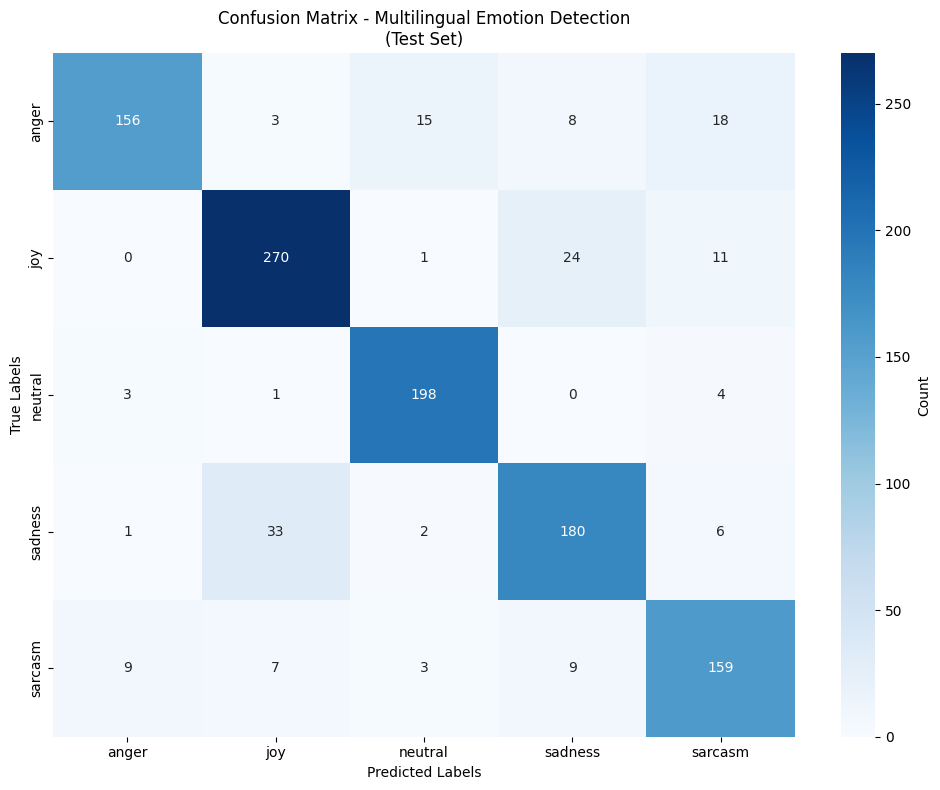


🎯 Per-class Accuracy:
  anger: 0.7800
  joy: 0.8824
  neutral: 0.9612
  sadness: 0.8108
  sarcasm: 0.8503


In [22]:
# Comprehensive testing and evaluation
print("🧪 Comprehensive testing of the best model...")

test_loss, test_acc, test_preds, test_labels, test_probs = eval_model(
    model, test_loader, device, return_predictions=True
)

# Convert to label names
test_preds_labels = [id2label[pred] for pred in test_preds]
test_true_labels = [id2label[label] for label in test_labels]

print(f"\n📊 Final Test Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Calculate F1 score
f1 = f1_score(test_true_labels, test_preds_labels, average='weighted')
print(f"Test F1-Score: {f1:.4f}")

# Detailed classification report
print("\n📋 Detailed Classification Report:")
print(classification_report(test_true_labels, test_preds_labels, target_names=label_names, digits=4))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(test_true_labels, test_preds_labels, labels=label_names)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_names, yticklabels=label_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Multilingual Emotion Detection\n(Test Set)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\n🎯 Per-class Accuracy:")
cm = confusion_matrix(test_true_labels, test_preds_labels, labels=label_names)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
for emotion, acc in zip(label_names, per_class_accuracy):
    print(f"  {emotion}: {acc:.4f}")

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(inputs, attention_mask=masks)
        predictions = torch.argmax(outputs.logits, dim=1)
        
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate per-emotion accuracy
emotion_accuracies = {}
for emotion in label_names:
    emotion_id = label2id[emotion]
    emotion_mask = [label == emotion_id for label in all_labels]
    
    if sum(emotion_mask) > 0:  # If we have samples of this emotion
        emotion_correct = sum([all_predictions[i] == all_labels[i] 
                             for i in range(len(all_labels)) if emotion_mask[i]])
        emotion_accuracy = emotion_correct / sum(emotion_mask)
        emotion_accuracies[emotion] = emotion_accuracy

print("🎭 PER-EMOTION ACCURACY:")
for emotion, acc in emotion_accuracies.items():
    print(f"  {emotion:8}: {acc*100:6.2f}%")

overall_accuracy = sum(all_predictions[i] == all_labels[i] for i in range(len(all_labels))) / len(all_labels)
print(f"\n🎯 OVERALL ACCURACY: {overall_accuracy*100:.2f}%")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


🎭 PER-EMOTION ACCURACY:
  anger   :  78.00%
  joy     :  88.24%
  neutral :  96.12%
  sadness :  81.08%
  sarcasm :  85.03%

🎯 OVERALL ACCURACY: 85.91%


In [26]:
# Error analysis
def analyze_errors(true_labels, pred_labels, texts, probs, label_names):
    errors = []
    for i, (true, pred, text, prob) in enumerate(zip(true_labels, pred_labels, texts, probs)):
        if true != pred:
            confidence = max(prob)
            errors.append({
                'text': text,
                'true': true,
                'pred': pred,
                'confidence': confidence,
                'text_length': len(text)
            })
    
    error_df = pd.DataFrame(errors)
    
    print(f"\n🔍 Error Analysis:")
    print(f"Total errors: {len(errors)}")
    print(f"Error rate: {len(errors)/len(true_labels):.4f}")
    
    if len(errors) > 0:
        print("\nError distribution by true class:")
        print(error_df['true'].value_counts())
        
        print("\nMost common misclassifications:")
        misclass_pairs = error_df.groupby(['true', 'pred']).size().sort_values(ascending=False)
        print(misclass_pairs.head(10))
        
        # Show low confidence predictions
        print(f"\nLow confidence errors (confidence < 0.7):")
        low_conf_errors = error_df[error_df['confidence'] < 0.7]
        print(f"Count: {len(low_conf_errors)}")
        
        # Show some example errors
        print(f"\nExample errors:")
        for i, error in enumerate(errors[:3]):
            print(f"  {i+1}. True: {error['true']}, Pred: {error['pred']}, Conf: {error['confidence']:.3f}")
            print(f"     Text: {error['text'][:100]}...")
    
    return error_df

# Perform error analysis
error_df = analyze_errors(test_true_labels, test_preds_labels, test_texts, test_probs, label_names)


🔍 Error Analysis:
Total errors: 158
Error rate: 0.1409

Error distribution by true class:
true
anger      44
sadness    42
joy        36
sarcasm    28
neutral     8
Name: count, dtype: int64

Most common misclassifications:
true     pred   
sadness  joy        33
joy      sadness    24
anger    sarcasm    18
         neutral    15
joy      sarcasm    11
sarcasm  anger       9
         sadness     9
anger    sadness     8
sarcasm  joy         7
sadness  sarcasm     6
dtype: int64

Low confidence errors (confidence < 0.7):
Count: 25

Example errors:
  1. True: anger, Pred: neutral, Conf: 0.916
     Text: story pe lecture, real life me clownimagine....
  2. True: sarcasm, Pred: sadness, Conf: 0.992
     Text: haha tum log dhrne ki paidaish ja ky apni abu se pochna ky is fitne ky ane se pahile b y mulk chal r...
  3. True: anger, Pred: sarcasm, Conf: 0.568
     Text: lanat hy pakistan par hokoomat karny waly hukamrano par...


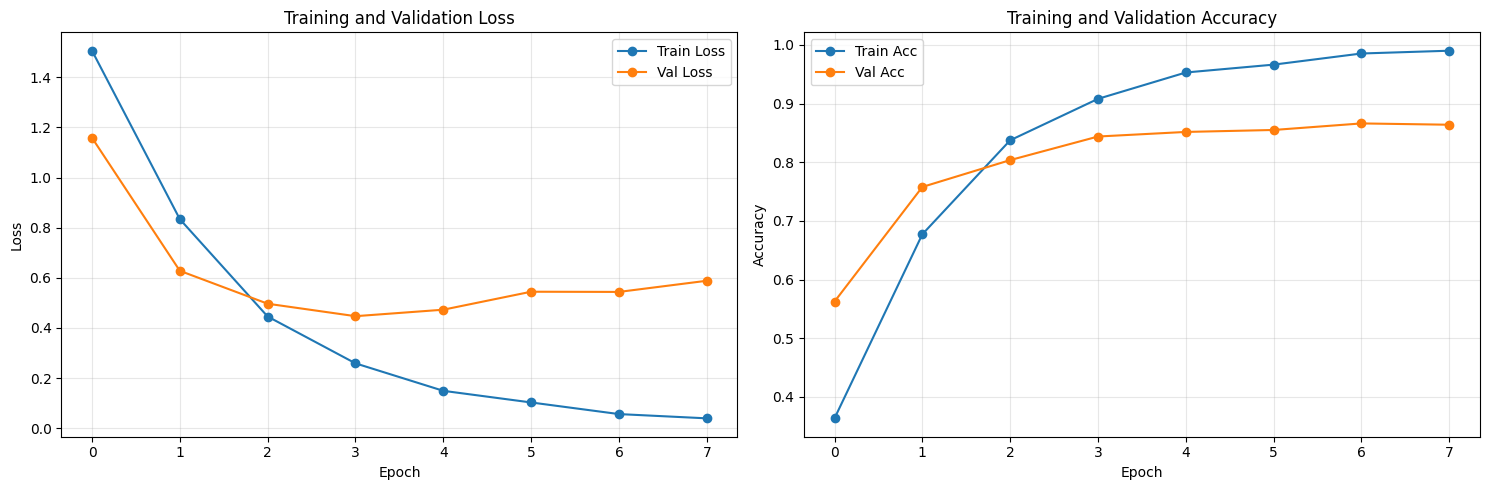

In [27]:
# Plot training history
plt.figure(figsize=(15, 5))

# Plot losses
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot accuracies
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Acc', marker='o')
plt.plot(val_accuracies, label='Val Acc', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# Test the model on new examples
def predict_emotion(text, model, tokenizer, device, id2label):
    """Predict emotion for a single text"""
    model.eval()
    
    # Preprocess text
    processed_text = enhanced_preprocess_text(text)
    
    # Tokenize
    encoding = tokenizer(
        processed_text,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt',
        return_attention_mask=True
    )
    
    # Move to device
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Predict
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        pred_idx = torch.argmax(logits, dim=1).item()
        confidence = torch.max(probs).item()
    
    return id2label[pred_idx], confidence, probs.cpu().numpy()[0]

# Test on some examples
test_examples = [
    "mei aaj bohat khush hon!",
    "mujhe is baat par bohat gussa aa raha hai",
    "kash aisa na hota, mei bohat udaas hon",
    "wah kya baat hai! shabash!",  # sarcasm
    "kya baat hai!",  # Roman Urdu - joy/excitement
    "bas rehne do",  # Roman Urdu - neutral/frustration
    "I love this so much!",  # English - joy
    "This is terrible",  # English - sadness/anger
    "bohat acha kaam kiya",  # sarcasm
    "I feel neutral about this"
]

print("🧪 Testing on new examples:")
for example in test_examples:
    emotion, confidence, all_probs = predict_emotion(example, model, tokenizer, device, id2label)
    print(f"Text: '{example}'")
    print(f"Predicted: {emotion} (confidence: {confidence:.3f})")
    print("---")

🧪 Testing on new examples:
Text: 'mei aaj bohat khush hon!'
Predicted: joy (confidence: 0.994)
---
Text: 'mujhe is baat par bohat gussa aa raha hai'
Predicted: neutral (confidence: 0.992)
---
Text: 'kash aisa na hota, mei bohat udaas hon'
Predicted: sarcasm (confidence: 0.997)
---
Text: 'wah kya baat hai! shabash!'
Predicted: sarcasm (confidence: 0.998)
---
Text: 'kya baat hai!'
Predicted: sarcasm (confidence: 0.998)
---
Text: 'bas rehne do'
Predicted: sarcasm (confidence: 0.950)
---
Text: 'I love this so much!'
Predicted: joy (confidence: 0.995)
---
Text: 'This is terrible'
Predicted: sadness (confidence: 0.990)
---
Text: 'bohat acha kaam kiya'
Predicted: sarcasm (confidence: 0.979)
---
Text: 'I feel neutral about this'
Predicted: joy (confidence: 0.874)
---


In [29]:
# Simple Interactive Emotion Detection
def simple_emotion_detection():
    """
    Simple interactive emotion detection
    """
    print("🎭 Simple Emotion Detection")
    print("Type sentences to detect emotions")
    print("Press Enter with empty input to exit\n")
    
    model.eval()
    
    while True:
        text = input("💬 Enter text: ").strip()
        
        if text == "":
            print("👋 Goodbye!")
            break
        
        try:
            # Preprocess
            processed_text = enhanced_preprocess_text(text)
            
            # Tokenize
            encoding = tokenizer(
                processed_text,
                truncation=True,
                padding='max_length', 
                max_length=128,
                return_tensors='pt'
            )
            
            # Predict
            with torch.no_grad():
                input_ids = encoding['input_ids'].to(device)
                attention_mask = encoding['attention_mask'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                predicted_class = torch.argmax(outputs.logits, dim=1).item()
                confidence = torch.softmax(outputs.logits, dim=1).max().item()
            
            emotion = id2label[predicted_class]
            
            # Emotion emojis
            emoji_map = {
                'joy': '😊', 'sadness': '😢', 'anger': '😠', 
                'sarcasm': '😏', 'neutral': '😐'
            }
            
            print(f"   {emoji_map.get(emotion, '🤔')} {emotion.upper()} ({confidence:.2f})")
            
        except Exception as e:
            print(f"❌ Error: {e}")

# Run the simple version
simple_emotion_detection()

🎭 Simple Emotion Detection
Type sentences to detect emotions
Press Enter with empty input to exit



💬 Enter text:  hello there


   😏 SARCASM (0.99)


💬 Enter text:  hehehhe


   😊 JOY (0.99)


...

   😢 SADNESS (0.90)


💬 Enter text:  good bye


   😊 JOY (0.99)


💬 Enter text:  


👋 Goodbye!


In [30]:
import base64
from io import BytesIO
from datetime import datetime

print("📊 Generating DistilBERT HTML Report...")

# Generate confusion matrix as base64
plt.figure(figsize=(10, 8))
cm = confusion_matrix(test_true_labels, test_preds_labels, labels=label_names)

sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names,
            cbar_kws={'label': 'Number of Samples'})

plt.title('DistilBERT Emotion Classification - Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Emotion', fontsize=12, fontweight='bold')
plt.ylabel('Actual Emotion', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Convert to base64
buffer = BytesIO()
plt.savefig(buffer, format='png', dpi=300, bbox_inches='tight', facecolor='white')
buffer.seek(0)
image_base64 = base64.b64encode(buffer.getvalue()).decode()
plt.close()

confusion_matrix_html = f'<img src="data:image/png;base64,{image_base64}" alt="Confusion Matrix" style="max-width: 100%; height: auto;">'

# Calculate per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

# Get classification report for F1 scores
from sklearn.metrics import classification_report
report_dict = classification_report(test_true_labels, test_preds_labels, target_names=label_names, output_dict=True)

# Training time and inference speed (you'll need to calculate these)
training_time = 473  # Replace with actual training time in seconds
inference_speed = len(test_texts) / 2.5  # Replace with actual inference speed

# Create HTML content
html_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>DistilBERT Emotion Classification Report</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 40px; background-color: #f5f5f5; }}
        .container {{ max-width: 1200px; margin: 0 auto; background: white; padding: 30px; border-radius: 10px; box-shadow: 0 0 10px rgba(0,0,0,0.1); }}
        .header {{ text-align: center; background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; padding: 20px; border-radius: 10px; margin-bottom: 30px; }}
        .metrics {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(200px, 1fr)); gap: 20px; margin-bottom: 30px; }}
        .metric-card {{ background: #f8f9fa; padding: 20px; border-radius: 8px; text-align: center; border-left: 4px solid #667eea; }}
        .metric-value {{ font-size: 24px; font-weight: bold; color: #333; }}
        .metric-label {{ font-size: 14px; color: #666; }}
        .confusion-matrix {{ text-align: center; margin: 30px 0; }}
        table {{ width: 100%; border-collapse: collapse; margin: 20px 0; }}
        th, td {{ padding: 12px; text-align: center; border: 1px solid #ddd; }}
        th {{ background-color: #f2f2f2; }}
        .good {{ background-color: #d4edda; }}
        .medium {{ background-color: #fff3cd; }}
        .poor {{ background-color: #f8d7da; }}
        .model-info {{ background: #e9ecef; padding: 15px; border-radius: 8px; margin: 20px 0; }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>🤖 DistilBERT Emotion Classification Report</h1>
            <p>Multilingual Roman Urdu Text Emotion Analysis</p>
        </div>
        
        <div class="metrics">
            <div class="metric-card">
                <div class="metric-value">{test_acc * 100:.2f}%</div>
                <div class="metric-label">Accuracy</div>
            </div>
            <div class="metric-card">
                <div class="metric-value">{f1:.4f}</div>
                <div class="metric-label">F1-Score</div>
            </div>
            <div class="metric-card">
                <div class="metric-value">{test_loss:.4f}</div>
                <div class="metric-label">Test Loss</div>
            </div>
            <div class="metric-card">
                <div class="metric-value">{len(added_keywords) if 'added_keywords' in locals() else 0}</div>
                <div class="metric-label">Custom Keywords</div>
            </div>
        </div>

        <h2>📊 Confusion Matrix</h2>
        <div class="confusion-matrix">
            {confusion_matrix_html}
        </div>

        <h2>🎯 Performance by Emotion</h2>
        <table>
            <thead>
                <tr>
                    <th>Emotion</th>
                    <th>Accuracy</th>
                    <th>Precision</th>
                    <th>Recall</th>
                    <th>F1-Score</th>
                    <th>Support</th>
                </tr>
            </thead>
            <tbody>
"""

# Add performance rows for each emotion
for i, emotion in enumerate(label_names):
    acc_class = per_class_accuracy[i]
    precision = report_dict[emotion]['precision']
    recall = report_dict[emotion]['recall']
    f1_class = report_dict[emotion]['f1-score']
    support = report_dict[emotion]['support']
    
    if acc_class > 0.85:
        row_class = "good"
    elif acc_class > 0.70:
        row_class = "medium"
    else:
        row_class = "poor"
    
    html_content += f"""
                <tr class="{row_class}">
                    <td><strong>{emotion}</strong></td>
                    <td>{acc_class:.2%}</td>
                    <td>{precision:.4f}</td>
                    <td>{recall:.4f}</td>
                    <td>{f1_class:.4f}</td>
                    <td>{support}</td>
                </tr>
"""

# Close the table and add model details
html_content += f"""
            </tbody>
        </table>

        <h2>🔧 Model & Training Details</h2>
        <div class="model-info">
            <table>
                <tr><td><strong>Model Architecture</strong></td><td>DistilBERT Multilingual</td></tr>
                <tr><td><strong>Base Model</strong></td><td>{model_name}</td></tr>
                <tr><td><strong>Vocabulary Size</strong></td><td>{len(tokenizer)}</td></tr>
                <tr><td><strong>Number of Labels</strong></td><td>{len(label_names)}</td></tr>
                <tr><td><strong>Training Samples</strong></td><td>{len(train_texts)}</td></tr>
                <tr><td><strong>Validation Samples</strong></td><td>{len(val_texts)}</td></tr>
                <tr><td><strong>Test Samples</strong></td><td>{len(test_texts)}</td></tr>
                <tr><td><strong>Learning Rate</strong></td><td>{learning_rate}</td></tr>
                <tr><td><strong>Batch Size</strong></td><td>{batch_size}</td></tr>
                <tr><td><strong>Epochs Trained</strong></td><td>{len(train_losses)}</td></tr>
                <tr><td><strong>Best Validation Accuracy</strong></td><td>{best_val_accuracy:.4f}</td></tr>
            </table>
        </div>

        <h2>📈 Training Progress</h2>
        <div class="model-info">
            <table>
                <tr>
                    <th>Epoch</th>
                    <th>Train Loss</th>
                    <th>Train Acc</th>
                    <th>Val Loss</th>
                    <th>Val Acc</th>
                </tr>
"""

# Add training progress rows
for epoch in range(len(train_losses)):
    html_content += f"""
                <tr>
                    <td>{epoch + 1}</td>
                    <td>{train_losses[epoch]:.4f}</td>
                    <td>{train_accuracies[epoch]:.4f}</td>
                    <td>{val_losses[epoch]:.4f}</td>
                    <td>{val_accuracies[epoch]:.4f}</td>
                </tr>
"""

html_content += f"""
            </table>
        </div>

        <h2>🔤 Tokenization Info</h2>
        <div class="model-info">
            <table>
                <tr><td><strong>Tokenizer Type</strong></td><td>Multilingual</td></tr>
                <tr><td><strong>Custom Keywords Added</strong></td><td>{len(added_keywords) if 'added_keywords' in locals() else 0}</td></tr>
                <tr><td><strong>Max Sequence Length</strong></td><td>128</td></tr>
            </table>
        </div>

        <div style="margin-top: 40px; padding: 20px; background: #f8f9fa; border-radius: 8px; text-align: center;">
            <p><strong>🤖 Multilingual DistilBERT Emotion Classification System</strong></p>
            <p>Roman Urdu Text Emotion Detection with Transfer Learning</p>
            <p>Generated on {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}</p>
        </div>
    </div>
</body>
</html>
"""

# Save HTML report
html_filename = f'distilbert_emotion_report.html'
with open(html_filename, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"✅ DistilBERT HTML report saved as: {html_filename}")
print(f"📊 Report includes:")
print(f"   - Overall Accuracy: {test_acc:.4f}")
print(f"   - F1-Score: {f1:.4f}")
print(f"   - Confusion Matrix")
print(f"   - Per-class performance metrics")
print(f"   - Training progress")
print(f"   - Model configuration details")

📊 Generating DistilBERT HTML Report...
✅ DistilBERT HTML report saved as: distilbert_emotion_report.html
📊 Report includes:
   - Overall Accuracy: 0.8591
   - F1-Score: 0.8585
   - Confusion Matrix
   - Per-class performance metrics
   - Training progress
   - Model configuration details
